# T4R + XGB Ensemble Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

## Config

In [2]:
# ── Ensemble weights (adjust these) ──
T4R_WEIGHT = 0.5
XGB_WEIGHT = 0.5

# ── File paths ──
T4R_PATH = "t4r_top40_predictions_20260318.csv"
XGB_PATH = "xgb_top40_predictions_20260319_0229.csv"

TOP_K_INPUT = 40

## Load Data & Run Ensemble

In [3]:
t4r_df = pd.read_csv(T4R_PATH)
xgb_df = pd.read_csv(XGB_PATH)

assert len(t4r_df) == len(xgb_df), f"Row count mismatch: {len(t4r_df)} vs {len(xgb_df)}"
n_samples = len(t4r_df)

gt_t4r = t4r_df["ground_truth"].values
gt_xgb = xgb_df["ground_truth_pid"].values
assert np.array_equal(gt_t4r, gt_xgb), "Ground truth mismatch!"
print(f"Loaded {n_samples} samples. Ground truths match.")


def parse_predictions(row, n_preds=40):
    items_probs = {}
    for r in range(1, n_preds + 1):
        item = row[f"pred_{r}_item"]
        prob = row[f"pred_{r}_prob"]
        if pd.notna(item) and pd.notna(prob):
            items_probs[int(item)] = float(prob)
    return items_probs


def recall_at_k(predicted_pids, ground_truth_pid, k):
    return int(ground_truth_pid in predicted_pids[:k])


def ndcg_at_k(predicted_pids, ground_truth_pid, k):
    for rank, pid in enumerate(predicted_pids[:k], start=1):
        if pid == ground_truth_pid:
            return 1.0 / np.log2(rank + 1)
    return 0.0


def run_ensemble(t4r_df, xgb_df, gt, t4r_weight, xgb_weight, top_k_input=40):
    """Run ensemble and return per-sample results."""
    n = len(t4r_df)
    TOP_K_EVAL = [20, 40]
    recalls = {k: [] for k in TOP_K_EVAL}
    ndcgs = {k: [] for k in TOP_K_EVAL}

    # Per-sample hit info
    t4r_hits_20, xgb_hits_20 = [], []
    t4r_hits_40, xgb_hits_40 = [], []
    ens_hits_20, ens_hits_40 = [], []
    t4r_ranks, xgb_ranks, ens_ranks = [], [], []
    overlaps_40 = []
    t4r_ndcgs = {k: [] for k in TOP_K_EVAL}
    xgb_ndcgs = {k: [] for k in TOP_K_EVAL}

    for i in range(n):
        g = int(gt[i])
        t4r_preds = parse_predictions(t4r_df.iloc[i], top_k_input)
        xgb_preds = parse_predictions(xgb_df.iloc[i], top_k_input)

        t4r_items = list(t4r_preds.keys())
        xgb_items = list(xgb_preds.keys())

        # Overlap
        overlaps_40.append(len(set(t4r_items) & set(xgb_items)))

        # Individual model hits
        t4r_hits_40.append(g in t4r_items)
        xgb_hits_40.append(g in xgb_items)
        t4r_hits_20.append(g in t4r_items[:20])
        xgb_hits_20.append(g in xgb_items[:20])

        # Individual model NDCG
        for k in TOP_K_EVAL:
            t4r_ndcgs[k].append(ndcg_at_k(t4r_items, g, k))
            xgb_ndcgs[k].append(ndcg_at_k(xgb_items, g, k))

        # Individual model ranks (1-indexed, None if not found)
        t4r_rank = (t4r_items.index(g) + 1) if g in t4r_items else None
        xgb_rank = (xgb_items.index(g) + 1) if g in xgb_items else None
        t4r_ranks.append(t4r_rank)
        xgb_ranks.append(xgb_rank)

        # Ensemble
        combined = {}
        for item in set(t4r_preds.keys()) | set(xgb_preds.keys()):
            score = 0.0
            if item in t4r_preds:
                score += t4r_weight * t4r_preds[item]
            if item in xgb_preds:
                score += xgb_weight * xgb_preds[item]
            combined[item] = score

        ranked = sorted(combined.items(), key=lambda x: x[1], reverse=True)
        ranked_items = [item for item, _ in ranked]

        ens_hits_20.append(g in ranked_items[:20])
        ens_hits_40.append(g in ranked_items[:40])
        ens_rank = (ranked_items.index(g) + 1) if g in ranked_items else None
        ens_ranks.append(ens_rank)

        for k in TOP_K_EVAL:
            recalls[k].append(recall_at_k(ranked_items, g, k))
            ndcgs[k].append(ndcg_at_k(ranked_items, g, k))

    results = {
        "recalls": recalls, "ndcgs": ndcgs,
        "t4r_ndcgs": t4r_ndcgs, "xgb_ndcgs": xgb_ndcgs,
        "t4r_hits_20": np.array(t4r_hits_20), "xgb_hits_20": np.array(xgb_hits_20),
        "t4r_hits_40": np.array(t4r_hits_40), "xgb_hits_40": np.array(xgb_hits_40),
        "ens_hits_20": np.array(ens_hits_20), "ens_hits_40": np.array(ens_hits_40),
        "t4r_ranks": t4r_ranks, "xgb_ranks": xgb_ranks, "ens_ranks": ens_ranks,
        "overlaps_40": np.array(overlaps_40),
    }
    return results


res = run_ensemble(t4r_df, xgb_df, gt_t4r, T4R_WEIGHT, XGB_WEIGHT, TOP_K_INPUT)

print(f"\nEnsemble weights: T4R={T4R_WEIGHT}, XGB={XGB_WEIGHT}")
print(f"{'='*55}")
print(f"{'Metric':<12} {'T4R':>10} {'XGB':>10} {'Ensemble':>10}")
print(f"{'-'*55}")
print(f"{'Recall@20':<12} {np.mean(res['t4r_hits_20']):>10.4f} {np.mean(res['xgb_hits_20']):>10.4f} {np.mean(res['recalls'][20]):>10.4f}")
print(f"{'Recall@40':<12} {np.mean(res['t4r_hits_40']):>10.4f} {np.mean(res['xgb_hits_40']):>10.4f} {np.mean(res['recalls'][40]):>10.4f}")
print(f"{'NDCG@20':<12} {np.mean(res['t4r_ndcgs'][20]):>10.4f} {np.mean(res['xgb_ndcgs'][20]):>10.4f} {np.mean(res['ndcgs'][20]):>10.4f}")
print(f"{'NDCG@40':<12} {np.mean(res['t4r_ndcgs'][40]):>10.4f} {np.mean(res['xgb_ndcgs'][40]):>10.4f} {np.mean(res['ndcgs'][40]):>10.4f}")

Loaded 2000 samples. Ground truths match.

Ensemble weights: T4R=0.5, XGB=0.5
Metric              T4R        XGB   Ensemble
-------------------------------------------------------
Recall@20        0.2920     0.3280     0.3385
Recall@40        0.3645     0.4245     0.4435
NDCG@20          0.1312     0.1476     0.1546
NDCG@40          0.1462     0.1673     0.1762


## Hit Heatmap — Top 40

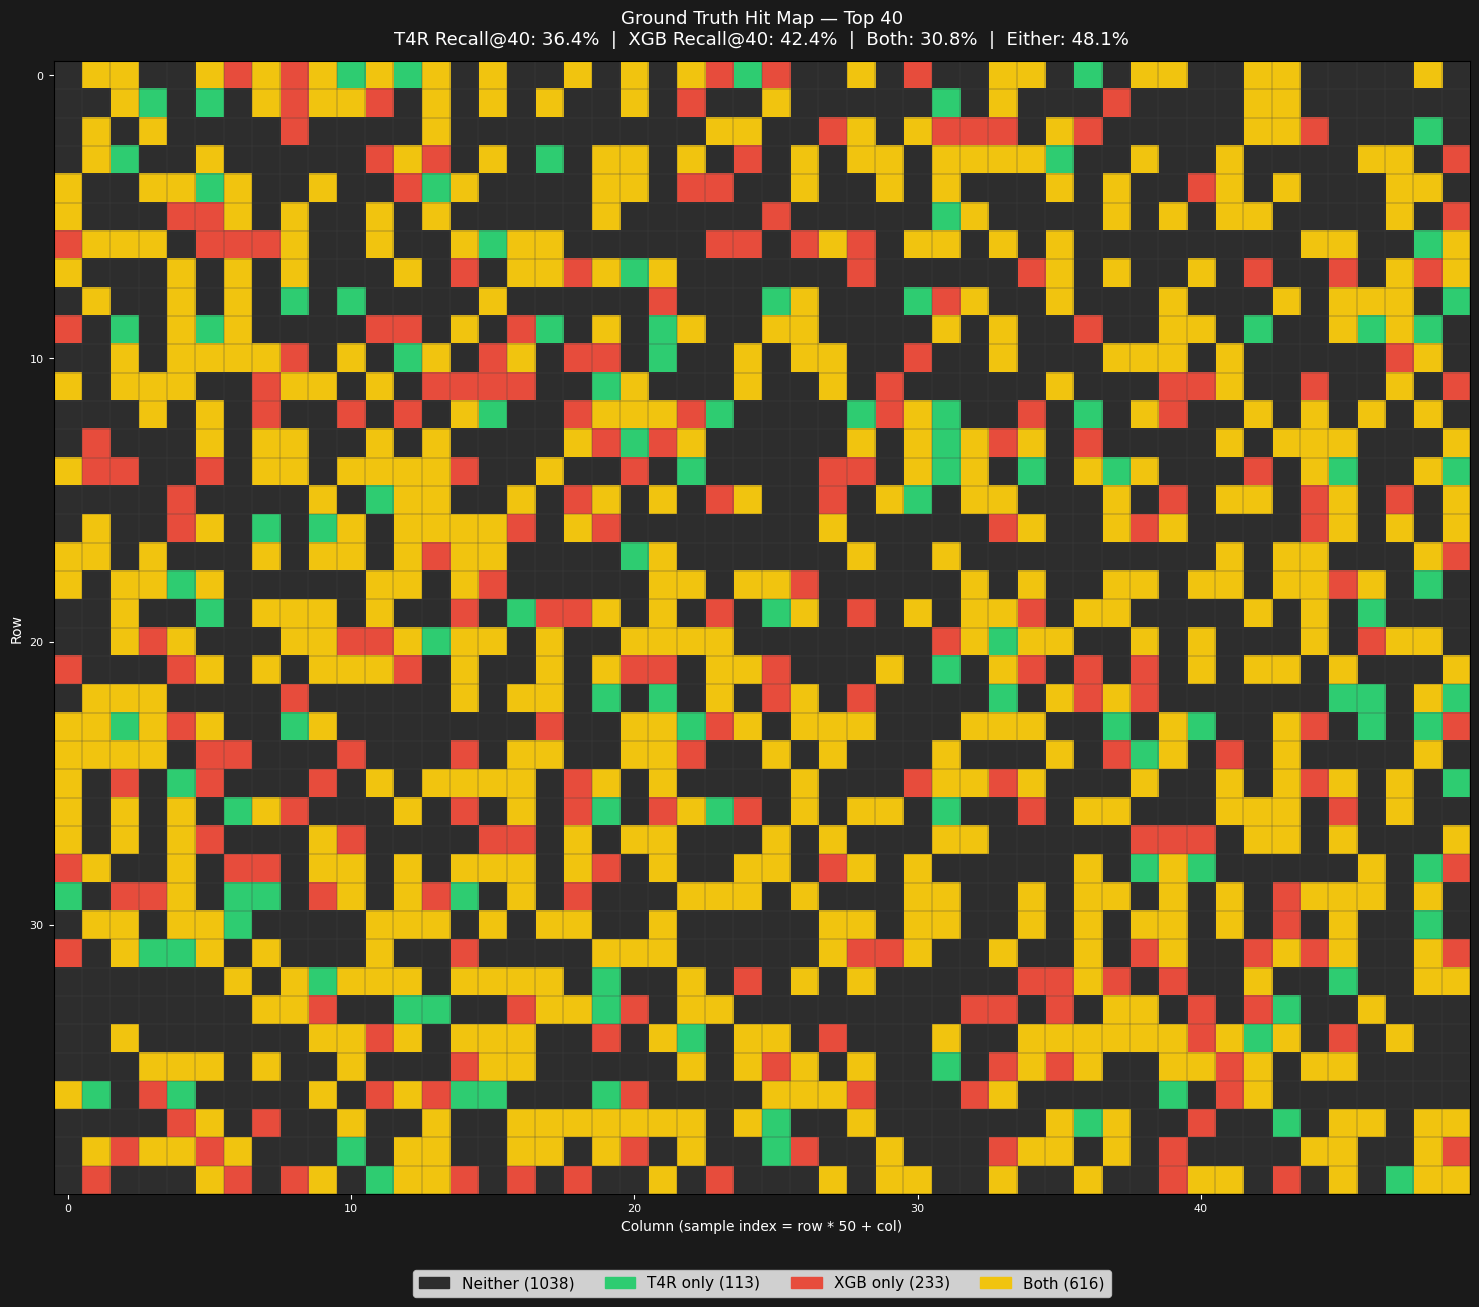

In [4]:
def plot_hit_heatmap(t4r_hits, xgb_hits, k, grid_rows=40, grid_cols=50):
    """
    Draw a heatmap of 2000 samples in a grid.
    Color coding:
      - Neither model hits: dark gray
      - T4R only: teal/green
      - XGB only: coral/red
      - Both hit: amber/gold
    """
    n = len(t4r_hits)
    assert n == grid_rows * grid_cols, f"Grid {grid_rows}x{grid_cols} != {n} samples"

    # 0=neither, 1=T4R only, 2=XGB only, 3=both
    codes = np.zeros(n, dtype=int)
    codes[t4r_hits & ~xgb_hits] = 1
    codes[~t4r_hits & xgb_hits] = 2
    codes[t4r_hits & xgb_hits] = 3
    grid = codes.reshape(grid_rows, grid_cols)

    # Colors: dark gray, teal, coral, gold
    cmap = mcolors.ListedColormap(["#2d2d2d", "#2ecc71", "#e74c3c", "#f1c40f"])
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    fig, ax = plt.subplots(figsize=(16, 13))
    im = ax.imshow(grid, cmap=cmap, norm=norm, aspect="equal", interpolation="nearest")

    # Grid lines
    ax.set_xticks(np.arange(-0.5, grid_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_rows, 1), minor=True)
    ax.grid(which="minor", color="#444444", linewidth=0.3)
    ax.tick_params(which="minor", size=0)

    # Axis labels (every 10)
    ax.set_xticks(np.arange(0, grid_cols, 10))
    ax.set_xticklabels(np.arange(0, grid_cols, 10), fontsize=8)
    ax.set_yticks(np.arange(0, grid_rows, 10))
    ax.set_yticklabels(np.arange(0, grid_rows, 10), fontsize=8)
    ax.set_xlabel("Column (sample index = row * 50 + col)", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    # Legend
    n_neither = np.sum(codes == 0)
    n_t4r = np.sum(codes == 1)
    n_xgb = np.sum(codes == 2)
    n_both = np.sum(codes == 3)
    patches = [
        mpatches.Patch(color="#2d2d2d", label=f"Neither ({n_neither})"),
        mpatches.Patch(color="#2ecc71", label=f"T4R only ({n_t4r})"),
        mpatches.Patch(color="#e74c3c", label=f"XGB only ({n_xgb})"),
        mpatches.Patch(color="#f1c40f", label=f"Both ({n_both})"),
    ]
    ax.legend(handles=patches, loc="upper center", bbox_to_anchor=(0.5, -0.06),
             ncol=4, fontsize=11, frameon=True, fancybox=True)

    hit_rate_t4r = np.mean(t4r_hits) * 100
    hit_rate_xgb = np.mean(xgb_hits) * 100
    ax.set_title(
        f"Ground Truth Hit Map — Top {k}\n"
        f"T4R Recall@{k}: {hit_rate_t4r:.1f}%  |  XGB Recall@{k}: {hit_rate_xgb:.1f}%  |  "
        f"Both: {n_both/n*100:.1f}%  |  Either: {(n_t4r+n_xgb+n_both)/n*100:.1f}%",
        fontsize=13, pad=12
    )

    fig.patch.set_facecolor("#1a1a1a")
    ax.set_facecolor("#1a1a1a")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")

    plt.tight_layout()
    plt.savefig(f"hit_heatmap_top{k}.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


plot_hit_heatmap(res["t4r_hits_40"], res["xgb_hits_40"], k=40)

## Hit Heatmap — Top 20

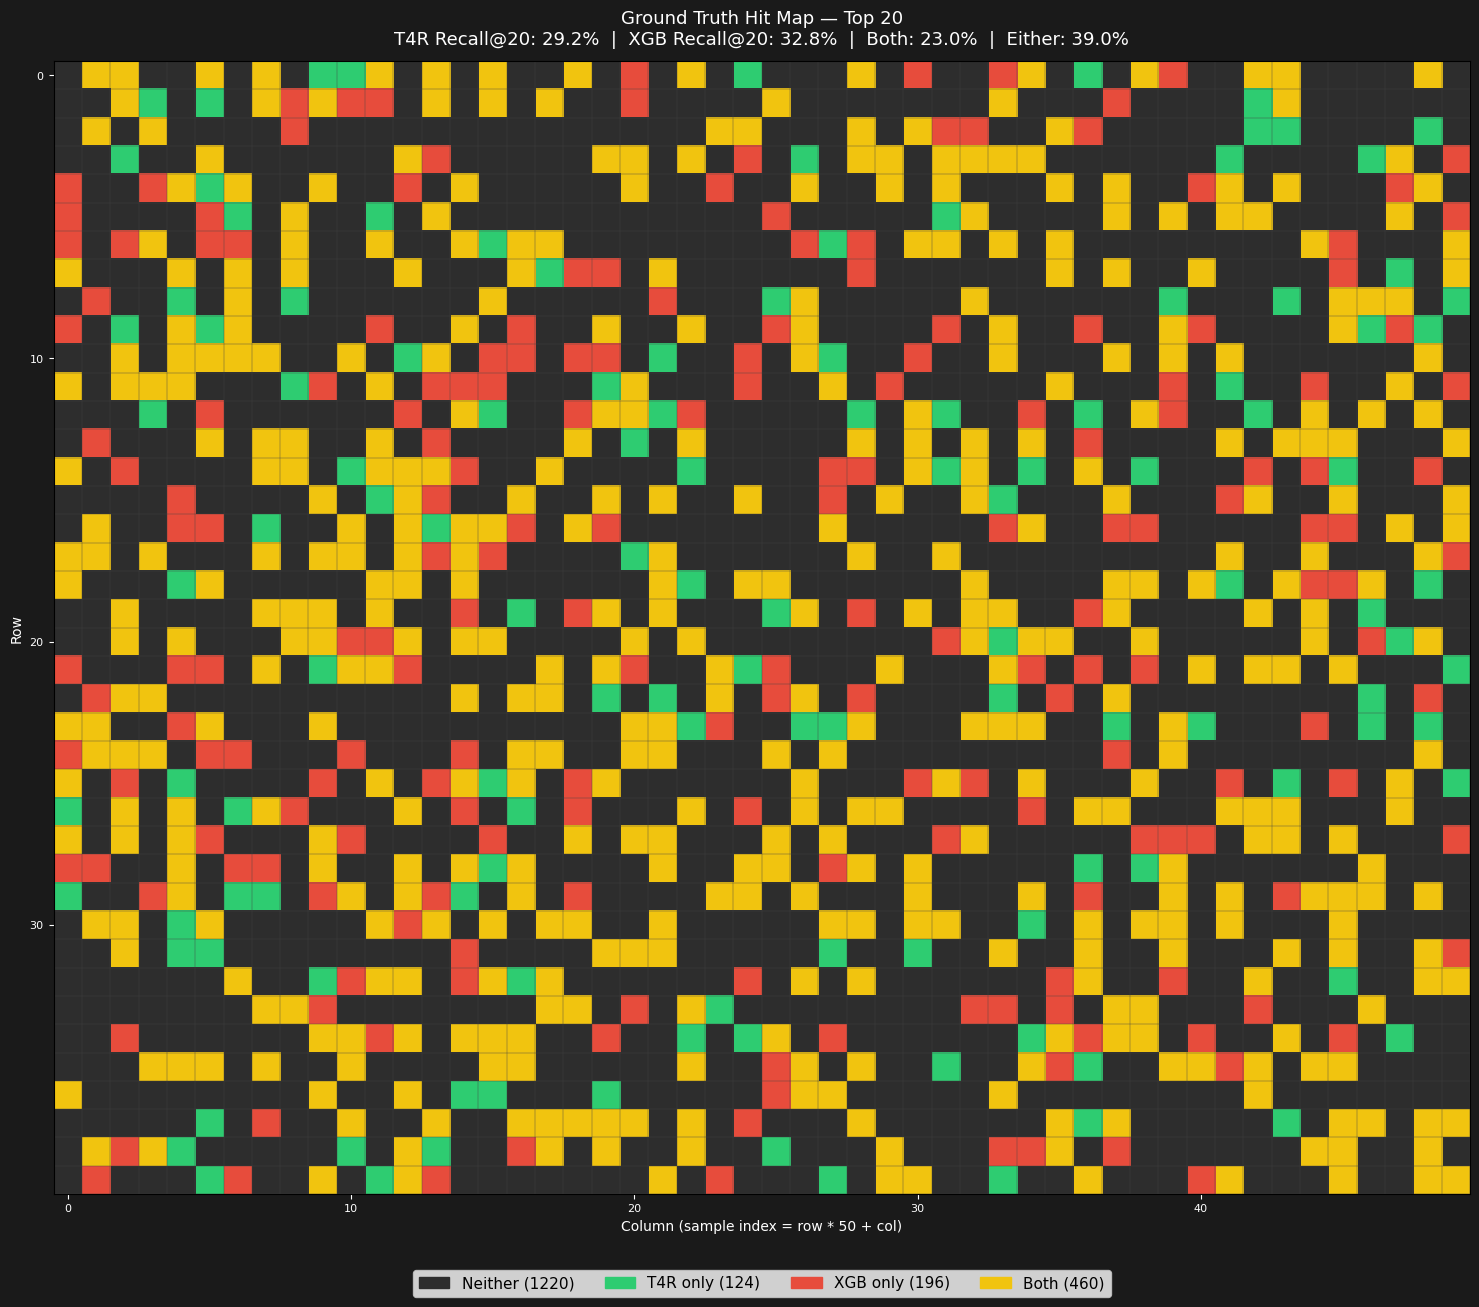

In [5]:
plot_hit_heatmap(res["t4r_hits_20"], res["xgb_hits_20"], k=20)

## Overlap Analysis

### 1. Hit Breakdown (Top-20 and Top-40)

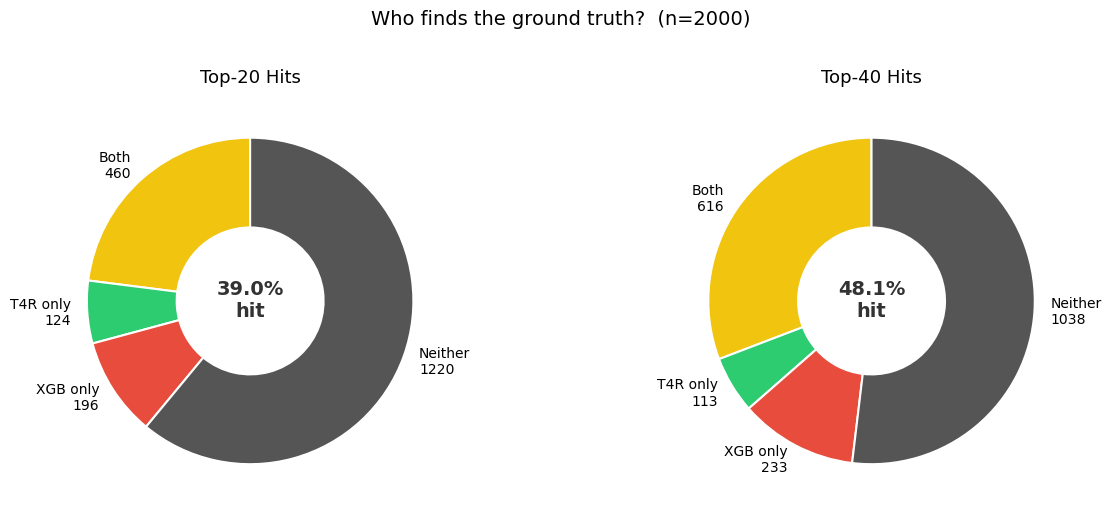

In [6]:
# Pure-matplotlib "Venn" replacement: side-by-side pie/donut charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, k_label, t4r_h, xgb_h in [
    (axes[0], 20, res["t4r_hits_20"], res["xgb_hits_20"]),
    (axes[1], 40, res["t4r_hits_40"], res["xgb_hits_40"]),
]:
    t4r_only = int(np.sum(t4r_h & ~xgb_h))
    xgb_only = int(np.sum(~t4r_h & xgb_h))
    both = int(np.sum(t4r_h & xgb_h))
    neither = int(np.sum(~t4r_h & ~xgb_h))

    sizes = [both, t4r_only, xgb_only, neither]
    colors = ["#f1c40f", "#2ecc71", "#e74c3c", "#555555"]
    labels = [f"Both\n{both}", f"T4R only\n{t4r_only}", f"XGB only\n{xgb_only}", f"Neither\n{neither}"]

    wedges, texts = ax.pie(
        sizes, labels=labels, colors=colors, startangle=90,
        wedgeprops=dict(width=0.55, edgecolor="white", linewidth=1.5),
        textprops=dict(fontsize=10),
    )
    # Percentage in center
    either_pct = (both + t4r_only + xgb_only) / n_samples * 100
    ax.text(0, 0, f"{either_pct:.1f}%\nhit", ha="center", va="center",
            fontsize=14, fontweight="bold", color="#333")
    ax.set_title(f"Top-{k_label} Hits", fontsize=13, pad=10)

plt.suptitle(f"Who finds the ground truth?  (n={n_samples})", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("hit_breakdown_donuts.png", dpi=150, bbox_inches="tight")
plt.show()

### 2. Item Overlap Distribution (how many of each model's top-40 items are shared)

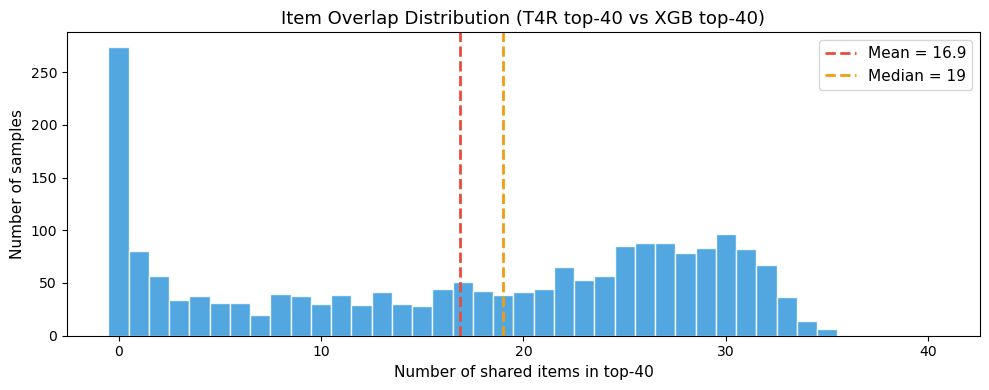

Min overlap: 0, Max overlap: 35
Samples with 0 overlap: 274
Samples with 30+ overlap: 302


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
overlaps = res["overlaps_40"]
ax.hist(overlaps, bins=np.arange(-0.5, 41.5, 1), color="#3498db", edgecolor="white", alpha=0.85)
ax.axvline(np.mean(overlaps), color="#e74c3c", linestyle="--", linewidth=2,
           label=f"Mean = {np.mean(overlaps):.1f}")
ax.axvline(np.median(overlaps), color="#f39c12", linestyle="--", linewidth=2,
           label=f"Median = {np.median(overlaps):.0f}")
ax.set_xlabel("Number of shared items in top-40", fontsize=11)
ax.set_ylabel("Number of samples", fontsize=11)
ax.set_title("Item Overlap Distribution (T4R top-40 vs XGB top-40)", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("overlap_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Min overlap: {overlaps.min()}, Max overlap: {overlaps.max()}")
print(f"Samples with 0 overlap: {np.sum(overlaps == 0)}")
print(f"Samples with 30+ overlap: {np.sum(overlaps >= 30)}")

### 3. Rank Comparison — When Both Models Find the Ground Truth

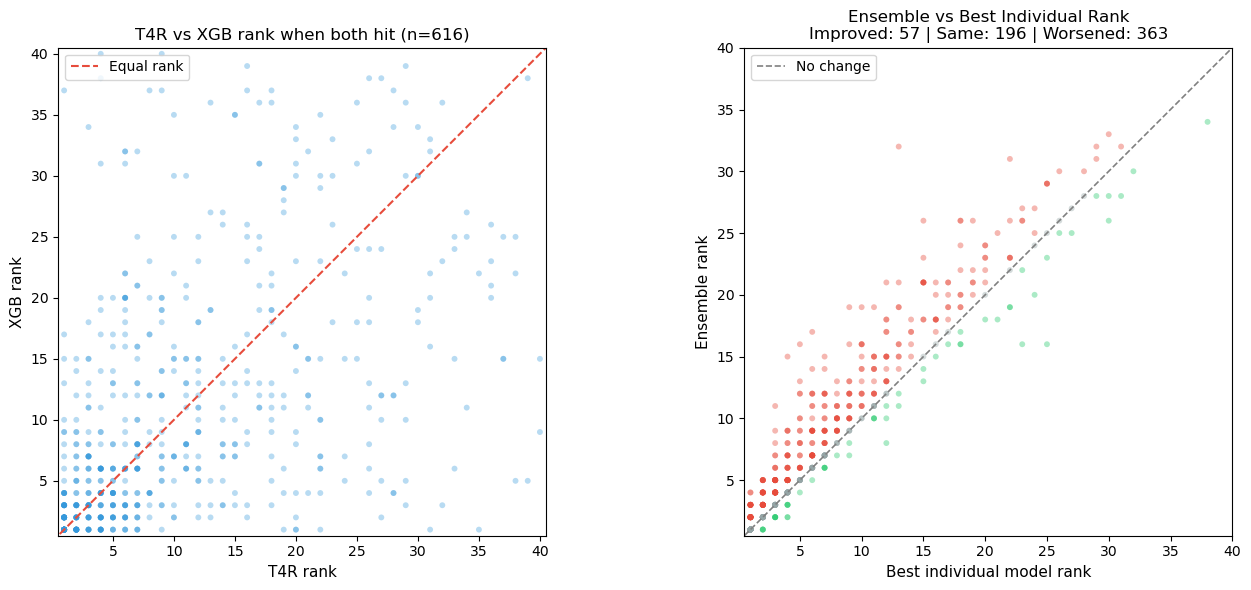

In [8]:
# Scatter plot: T4R rank vs XGB rank for samples where both find the GT
both_found = [(t, x, e) for t, x, e in zip(res["t4r_ranks"], res["xgb_ranks"], res["ens_ranks"])
              if t is not None and x is not None]

if both_found:
    t_ranks, x_ranks, e_ranks = zip(*both_found)
    t_ranks, x_ranks, e_ranks = np.array(t_ranks), np.array(x_ranks), np.array(e_ranks)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: T4R vs XGB rank
    ax = axes[0]
    ax.scatter(t_ranks, x_ranks, alpha=0.35, s=18, c="#3498db", edgecolors="none")
    ax.plot([0, 41], [0, 41], "--", color="#e74c3c", linewidth=1.5, label="Equal rank")
    ax.set_xlabel("T4R rank", fontsize=11)
    ax.set_ylabel("XGB rank", fontsize=11)
    ax.set_title(f"T4R vs XGB rank when both hit (n={len(both_found)})", fontsize=12)
    ax.set_xlim(0.5, 40.5)
    ax.set_ylim(0.5, 40.5)
    ax.legend(fontsize=10)
    ax.set_aspect("equal")

    # Right: rank improvement from ensemble
    ax = axes[1]
    best_individual = np.minimum(t_ranks, x_ranks)
    rank_change = e_ranks - best_individual  # negative = ensemble improved
    colors = np.where(rank_change < 0, "#2ecc71", np.where(rank_change > 0, "#e74c3c", "#95a5a6"))
    ax.scatter(best_individual, e_ranks, alpha=0.4, s=18, c=colors, edgecolors="none")
    ax.plot([0, 65], [0, 65], "--", color="gray", linewidth=1.2, label="No change")
    ax.set_xlabel("Best individual model rank", fontsize=11)
    ax.set_ylabel("Ensemble rank", fontsize=11)
    improved = np.sum(rank_change < 0)
    worsened = np.sum(rank_change > 0)
    same = np.sum(rank_change == 0)
    ax.set_title(
        f"Ensemble vs Best Individual Rank\n"
        f"Improved: {improved} | Same: {same} | Worsened: {worsened}",
        fontsize=12
    )
    lim = max(best_individual.max(), e_ranks.max()) + 2
    ax.set_xlim(0.5, lim)
    ax.set_ylim(0.5, lim)
    ax.legend(fontsize=10)
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.savefig("rank_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No samples where both models found the ground truth.")

### 4. Ensemble Rescue Analysis — Did ensemble surface hits that neither model had in top-20?

In [9]:
# Cases where ensemble@20 hits but neither individual model@20 hits
# (The item was ranked 21-40 in one or both models, and ensemble boosted it into top-20)
rescued_20 = res["ens_hits_20"] & ~res["t4r_hits_20"] & ~res["xgb_hits_20"]
rescued_by_t4r = res["ens_hits_20"] & ~res["t4r_hits_20"] & res["xgb_hits_20"]  # XGB had it, T4R didn't
rescued_by_xgb = res["ens_hits_20"] & res["t4r_hits_20"] & ~res["xgb_hits_20"]  # T4R had it, XGB didn't

# Cases where individual model@20 hit but ensemble@20 lost it
lost_t4r = res["t4r_hits_20"] & ~res["ens_hits_20"]
lost_xgb = res["xgb_hits_20"] & ~res["ens_hits_20"]

print("=" * 55)
print("Ensemble@20 Rescue & Loss Analysis")
print("=" * 55)
print(f"Ensemble rescued (neither model had in top-20): {rescued_20.sum()}")
print(f"  - Item was in XGB@20, not T4R@20, ensemble kept: {rescued_by_t4r.sum()}")
print(f"  - Item was in T4R@20, not XGB@20, ensemble kept: {rescued_by_xgb.sum()}")
print(f"")
print(f"Ensemble lost (model had in top-20, ensemble dropped):")
print(f"  - Was in T4R@20, lost by ensemble: {lost_t4r.sum()}")
print(f"  - Was in XGB@20, lost by ensemble: {lost_xgb.sum()}")
print(f"")
print(f"Net gain over T4R@20: +{(res['ens_hits_20'].sum() - res['t4r_hits_20'].sum())} hits")
print(f"Net gain over XGB@20: +{(res['ens_hits_20'].sum() - res['xgb_hits_20'].sum())} hits")

Ensemble@20 Rescue & Loss Analysis
Ensemble rescued (neither model had in top-20): 6
  - Item was in XGB@20, not T4R@20, ensemble kept: 157
  - Item was in T4R@20, not XGB@20, ensemble kept: 54

Ensemble lost (model had in top-20, ensemble dropped):
  - Was in T4R@20, lost by ensemble: 70
  - Was in XGB@20, lost by ensemble: 39

Net gain over T4R@20: +93 hits
Net gain over XGB@20: +21 hits


### 5. Conditional Hit Rate — Does overlap predict ensemble success?

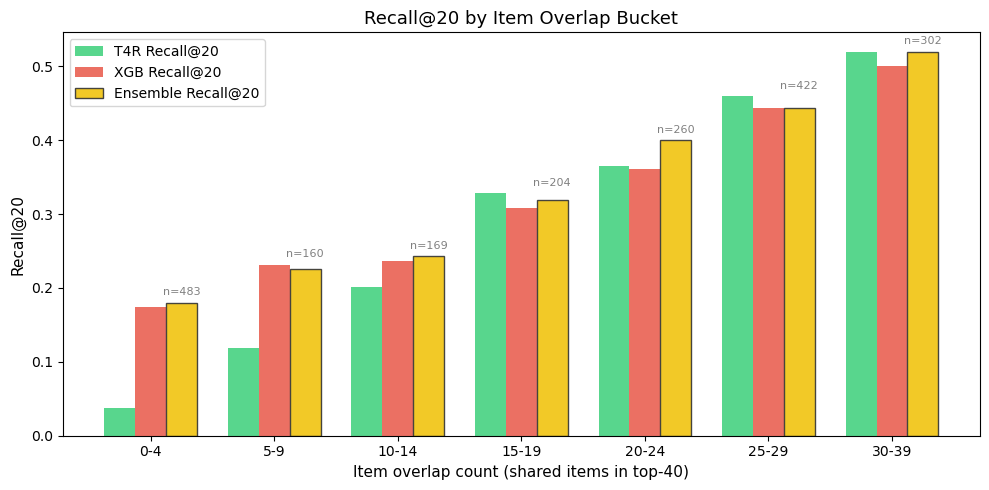

In [10]:
# Bin samples by overlap count, show ensemble recall@20 per bin
overlaps = res["overlaps_40"]
ens_h20 = res["ens_hits_20"]

# Create bins
bins = [(0, 5), (5, 10), (10, 15), (15, 20), (20, 25), (25, 30), (30, 40)]
bin_labels = []
bin_recall_ens = []
bin_recall_t4r = []
bin_recall_xgb = []
bin_counts = []

for lo, hi in bins:
    mask = (overlaps >= lo) & (overlaps < hi)
    n_bin = mask.sum()
    if n_bin == 0:
        continue
    bin_labels.append(f"{lo}-{hi-1}")
    bin_counts.append(n_bin)
    bin_recall_ens.append(np.mean(ens_h20[mask]))
    bin_recall_t4r.append(np.mean(res["t4r_hits_20"][mask]))
    bin_recall_xgb.append(np.mean(res["xgb_hits_20"][mask]))

fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(bin_labels))
width = 0.25

ax1.bar(x - width, bin_recall_t4r, width, label="T4R Recall@20", color="#2ecc71", alpha=0.8)
ax1.bar(x, bin_recall_xgb, width, label="XGB Recall@20", color="#e74c3c", alpha=0.8)
ax1.bar(x + width, bin_recall_ens, width, label="Ensemble Recall@20", color="#f1c40f", alpha=0.9, edgecolor="#333")

ax1.set_xlabel("Item overlap count (shared items in top-40)", fontsize=11)
ax1.set_ylabel("Recall@20", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(bin_labels)
ax1.legend(fontsize=10)

# Add sample counts on top
for i, c in enumerate(bin_counts):
    ax1.text(i + width, max(bin_recall_ens[i], bin_recall_t4r[i], bin_recall_xgb[i]) + 0.01,
             f"n={c}", ha="center", fontsize=8, color="gray")

ax1.set_title("Recall@20 by Item Overlap Bucket", fontsize=13)
plt.tight_layout()
plt.savefig("recall_by_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

### 6. Model Agreement Breakdown — Stacked Bar

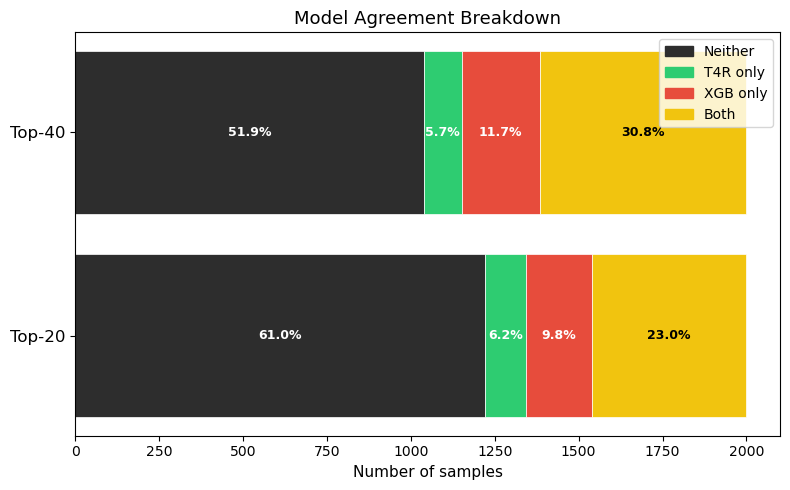

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

categories = ["Top-20", "Top-40"]
for idx, (k_label, t4r_h, xgb_h, ens_h) in enumerate([
    ("Top-20", res["t4r_hits_20"], res["xgb_hits_20"], res["ens_hits_20"]),
    ("Top-40", res["t4r_hits_40"], res["xgb_hits_40"], res["ens_hits_40"]),
]):
    neither = np.sum(~t4r_h & ~xgb_h)
    t4r_only = np.sum(t4r_h & ~xgb_h)
    xgb_only = np.sum(~t4r_h & xgb_h)
    both = np.sum(t4r_h & xgb_h)

    bars = [neither, t4r_only, xgb_only, both]
    colors = ["#2d2d2d", "#2ecc71", "#e74c3c", "#f1c40f"]
    labels_inner = ["Neither", "T4R only", "XGB only", "Both"]

    left = 0
    for j, (val, col) in enumerate(zip(bars, colors)):
        pct = val / n_samples * 100
        bar = ax.barh(idx, val, left=left, color=col, edgecolor="white", linewidth=0.5)
        if pct > 4:  # only label if wide enough
            ax.text(left + val / 2, idx, f"{pct:.1f}%",
                    ha="center", va="center", fontsize=9,
                    color="white" if j != 3 else "black", fontweight="bold")
        left += val

ax.set_yticks([0, 1])
ax.set_yticklabels(categories, fontsize=12)
ax.set_xlabel("Number of samples", fontsize=11)
ax.set_title("Model Agreement Breakdown", fontsize=13)

patches = [mpatches.Patch(color=c, label=l)
           for c, l in zip(["#2d2d2d", "#2ecc71", "#e74c3c", "#f1c40f"],
                           ["Neither", "T4R only", "XGB only", "Both"])]
ax.legend(handles=patches, loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig("agreement_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

### 7. Metric Comparison Bar Chart

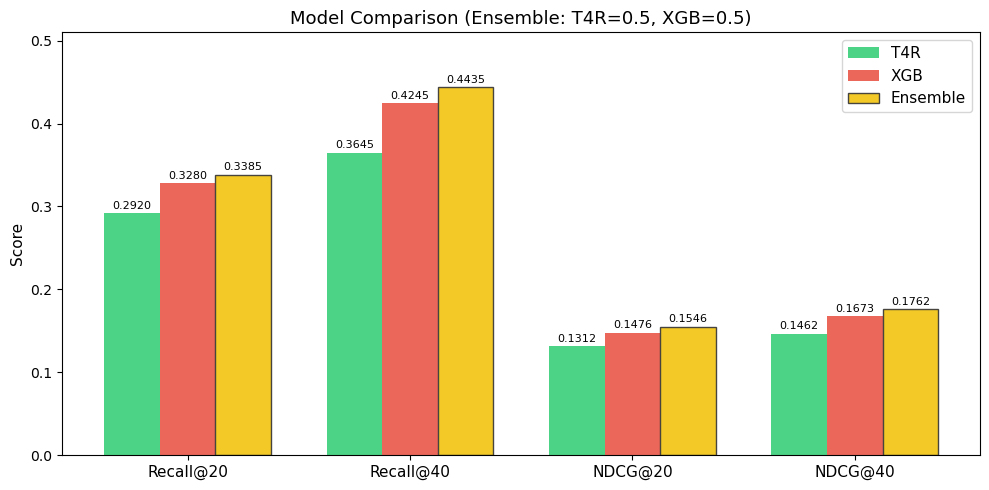

In [12]:
# Side-by-side comparison of all metrics
metrics = ["Recall@20", "Recall@40", "NDCG@20", "NDCG@40"]
t4r_vals = [
    np.mean(res["t4r_hits_20"]),
    np.mean(res["t4r_hits_40"]),
    np.mean(res["t4r_ndcgs"][20]),
    np.mean(res["t4r_ndcgs"][40]),
]
xgb_vals = [
    np.mean(res["xgb_hits_20"]),
    np.mean(res["xgb_hits_40"]),
    np.mean(res["xgb_ndcgs"][20]),
    np.mean(res["xgb_ndcgs"][40]),
]
ens_vals = [
    np.mean(res["recalls"][20]),
    np.mean(res["recalls"][40]),
    np.mean(res["ndcgs"][20]),
    np.mean(res["ndcgs"][40]),
]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, t4r_vals, width, label="T4R", color="#2ecc71", alpha=0.85)
bars2 = ax.bar(x, xgb_vals, width, label="XGB", color="#e74c3c", alpha=0.85)
bars3 = ax.bar(x + width, ens_vals, width, label="Ensemble", color="#f1c40f", alpha=0.9, edgecolor="#333")

# Value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
                f"{h:.4f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(f"Model Comparison (Ensemble: T4R={T4R_WEIGHT}, XGB={XGB_WEIGHT})", fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(t4r_vals), max(xgb_vals), max(ens_vals)) * 1.15)

plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 8. Per-Sample Rank Shift Histogram

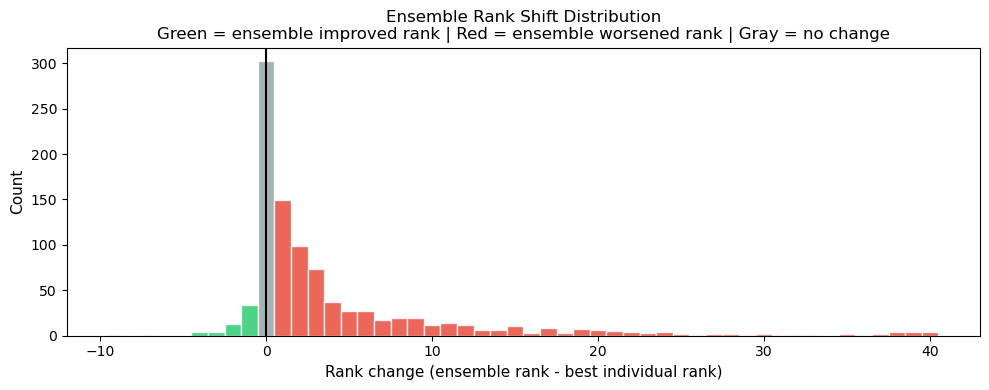

Median rank shift: 1
Mean rank shift: 4.13
Improved: 57 | Same: 302 | Worsened: 603


In [13]:
# For samples where at least one model found the GT, how does ensemble rank compare?
rank_shifts = []
for t, x, e in zip(res["t4r_ranks"], res["xgb_ranks"], res["ens_ranks"]):
    if e is None:
        continue
    best_indiv = min(r for r in [t, x] if r is not None)
    rank_shifts.append(e - best_indiv)

rank_shifts = np.array(rank_shifts)

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(rank_shifts.min() - 0.5, rank_shifts.max() + 1.5, 1)
colors_hist = ["#2ecc71" if b < 0 else ("#95a5a6" if b == 0 else "#e74c3c")
               for b in range(int(rank_shifts.min()), int(rank_shifts.max()) + 1)]
n_vals, bin_edges, patches_hist = ax.hist(rank_shifts, bins=bins, edgecolor="white", alpha=0.85)
for patch, color in zip(patches_hist, colors_hist):
    patch.set_facecolor(color)

ax.axvline(0, color="black", linewidth=1.5, linestyle="-")
ax.set_xlabel("Rank change (ensemble rank - best individual rank)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(
    f"Ensemble Rank Shift Distribution\n"
    f"Green = ensemble improved rank | Red = ensemble worsened rank | Gray = no change",
    fontsize=12
)
plt.tight_layout()
plt.savefig("rank_shift_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median rank shift: {np.median(rank_shifts):.0f}")
print(f"Mean rank shift: {np.mean(rank_shifts):.2f}")
print(f"Improved: {np.sum(rank_shifts < 0)} | Same: {np.sum(rank_shifts == 0)} | Worsened: {np.sum(rank_shifts > 0)}")